In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/ecommerce_sales.csv")

In [4]:
df.head()

,Order_ID,Order_Date,Platform,Customer_ID,Product,Price,Quantity,Discount,Revenue,Country
0,916abd86,2024-05-16,Shopify,1eeefe,Headphones,264.78,3,0.16,667.25,Guinea
1,1e85b738,2024-04-10,Amazon,7a0154,Tablet,809.56,2,0.09,1473.40,Monaco
2,a5643451,2024-07-19,Shopify,3ef0de,Headphones,520.08,2,0.09,946.55,Dominica
3,27a8689c,2025-01-18,Shopify,d9e313,Smartwatch,80.61,4,0.12,283.75,Dominica
4,630b1112,2024-08-20,Amazon,8f32ea,Tablet,752.19,4,0.00,3008.76,Isle of Man


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     5000 non-null   object 
 1   Order_Date   5000 non-null   object 
 2   Platform     5000 non-null   object 
 3   Customer_ID  5000 non-null   object 
 4   Product      5000 non-null   object 
 5   Price        5000 non-null   float64
 6   Quantity     5000 non-null   int64  
 7   Discount     5000 non-null   float64
 8   Revenue      5000 non-null   float64
 9   Country      5000 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 390.8+ KB


In [6]:
df.shape

(5000, 10)

In [7]:
df.isnull().sum()

Order_ID       0
Order_Date     0
Platform       0
Customer_ID    0
Product        0
Price          0
Quantity       0
Discount       0
Revenue        0
Country        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Order_ID        object
Order_Date      object
Platform        object
Customer_ID     object
Product         object
Price          float64
Quantity         int64
Discount       float64
Revenue        float64
Country         object
dtype: object

In [10]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [11]:
df.dtypes

Order_ID               object
Order_Date     datetime64[ns]
Platform               object
Customer_ID            object
Product                object
Price                 float64
Quantity                int64
Discount              float64
Revenue               float64
Country                object
dtype: object

In [12]:
df['Order_Date'].min()

Timestamp('2024-02-04 00:00:00')

In [13]:
df['Order_Date'].max()

Timestamp('2025-02-03 00:00:00')

In [14]:
df['Price'].describe()

count    5000.000000
mean     1027.793070
std       561.689567
min        50.360000
25%       555.485000
50%      1031.070000
75%      1508.092500
max      1999.710000
Name: Price, dtype: float64

In [15]:
df['Quantity'].describe()

count    5000.00000
mean        2.49400
std         1.11221
min         1.00000
25%         2.00000
50%         2.00000
75%         3.00000
max         4.00000
Name: Quantity, dtype: float64

In [16]:
df['Discount'].describe()

count    5000.000000
mean        0.148628
std         0.086152
min         0.000000
25%         0.070000
50%         0.150000
75%         0.220000
max         0.300000
Name: Discount, dtype: float64

In [17]:
df['Revenue'].describe()

count    5000.000000
mean     2192.283730
std      1663.952857
min        40.330000
25%       870.937500
50%      1714.370000
75%      3226.707500
max      7915.880000
Name: Revenue, dtype: float64

In [22]:
df['Calculated_Revenue']=(
    df['Price'] * df['Quantity'] *(1-df['Discount'])
)


In [23]:
df['Revenue_Difference'] = (
    df['Revenue'] - df['Calculated_Revenue']
).abs()

df['Revenue_Difference'].max()

np.float64(0.005000000000109139)

In [25]:
df['Platform'].value_counts()

Platform
Amazon     1738
eBay       1640
Shopify    1622
Name: count, dtype: int64

In [28]:
platform_revenue=df.groupby('Platform')['Revenue'].sum().sort_values(ascending=False)

platform_revenue


Platform
Amazon     3690222.01
eBay       3664223.98
Shopify    3606972.66
Name: Revenue, dtype: float64

In [29]:
product_revenue=df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

product_revenue

Product
Camera        1676350.78
Smartphone    1657517.88
Tablet        1615959.98
Monitor       1558730.53
Headphones    1543274.68
Smartwatch    1493942.47
Laptop        1415642.33
Name: Revenue, dtype: float64

In [31]:
df['Month']=df['Order_Date'].dt.to_period('M').astype(str)

monthly_revenue=(
    df.groupby('Month')['Revenue']
    .sum()
    .sort_index()
)

monthly_revenue



Month
2024-02     856774.78
2024-03     860987.52
2024-04     894849.66
2024-05     905887.70
2024-06     867441.19
2024-07     980044.63
2024-08     916193.70
2024-09     849021.09
2024-10     885918.13
2024-11     840984.38
2024-12     924371.85
2025-01    1088257.87
2025-02      90686.15
Name: Revenue, dtype: float64

In [33]:
country_revenue= (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
New Caledonia                        87054.29
Korea                                85613.33
Kazakhstan                           81238.47
Guyana                               71537.49
Heard Island and McDonald Islands    70968.69
Sao Tome and Principe                70668.66
Russian Federation                   70099.76
Faroe Islands                        67916.86
Puerto Rico                          67241.28
El Salvador                          67011.39
Name: Revenue, dtype: float64

In [34]:
product_quantity= (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

product_quantity 

Product
Smartphone    1930
Camera        1858
Tablet        1812
Monitor       1800
Smartwatch    1730
Headphones    1704
Laptop        1636
Name: Quantity, dtype: int64

In [35]:
aov_platform= (
    df.groupby('Platform')['Revenue']
    .mean()
    .sort_values(ascending=False)

)
aov_platform

Platform
eBay       2234.282915
Shopify    2223.780925
Amazon     2123.257773
Name: Revenue, dtype: float64

In [36]:
discount_analysis= (
    df.groupby('Discount')['Revenue']
    .mean()
    .sort_index()
)

discount_analysis

Discount
0.00    2569.616027
0.01    2659.357293
0.02    2799.382041
0.03    2474.695948
0.04    2411.382951
0.05    2569.913245
0.06    2205.203068
0.07    2484.381867
0.08    2486.637178
0.09    2278.599434
0.10    2399.972540
0.11    2356.602682
0.12    2048.118580
0.13    2291.991069
0.14    2334.226358
0.15    2158.035000
0.16    2272.896763
0.17    2015.200773
0.18    2278.838889
0.19    1940.245030
0.20    1992.293882
0.21    1961.797472
0.22    1855.124286
0.23    1797.611037
0.24    1943.032048
0.25    1938.181895
0.26    1749.894248
0.27    1892.720000
0.28    1948.876242
0.29    1940.195765
0.30    1778.450000
Name: Revenue, dtype: float64

In [38]:
df[['Discount','Revenue']].corr()

,Discount,Revenue
Discount,1.000000,-0.148903
Revenue,-0.148903,1.000000


In [39]:
customer_revenue= (
    df.groupby('Customer_ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)


Customer_ID
a5b408    7915.88
1b5cbf    7846.90
19de66    7821.28
f6dd63    7805.52
4148ad    7803.85
da4469    7764.89
206754    7667.40
f1d79b    7607.12
33fe6a    7602.80
880cb1    7527.39
Name: Revenue, dtype: float64

In [42]:
customer_orders = (
    df.groupby('Customer_ID')['Order_ID']
      .count()
      .sort_values(ascending=False)
)

customer_orders.head(10)

Customer_ID
00076d    1
000b1e    1
000cef    1
001336    1
001b78    1
0022fc    1
0030bc    1
003787    1
003cba    1
004864    1
Name: Order_ID, dtype: int64

In [43]:
df['Customer_ID'].nunique()

5000

In [44]:
total_revenue=df['Revenue'].sum()
total_orders=df['Order_ID'].nunique()
total_quantity=df['Quantity'].sum()
avg_order_value=df['Revenue'].mean()

print("Total Revenue:",total_revenue)
print("Total Orders:",total_orders)
print("Total Quantity:",total_quantity)
print("Average Order Value:",avg_order_value)

                                    

Total Revenue: 10961418.649999999
Total Orders: 5000
Total Quantity: 12470
Average Order Value: 2192.2837299999997


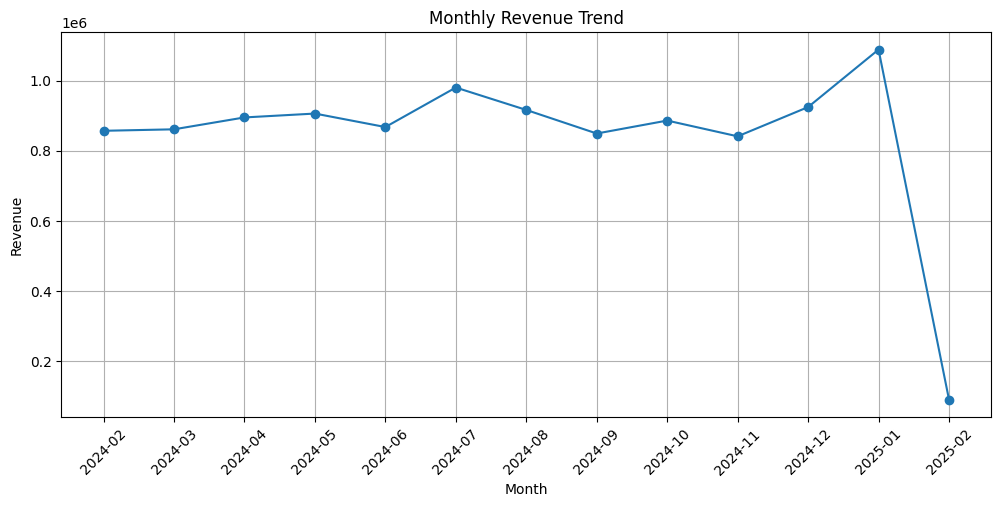

In [47]:
# Monthly Revenue Trend

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

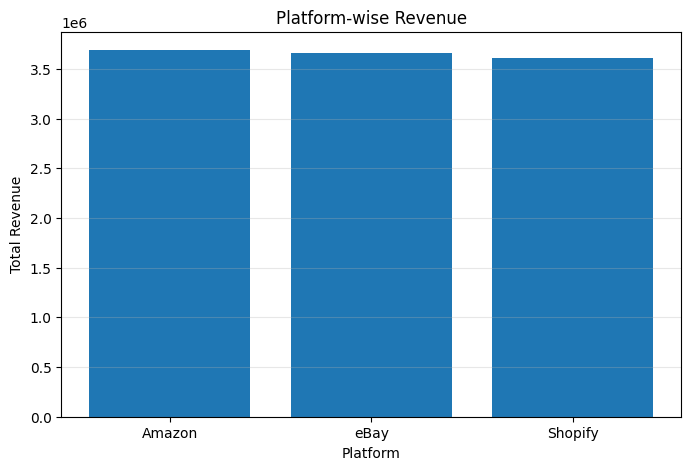

In [49]:
# platform-wise Revenue Comparison

plt.figure(figsize=(8, 5))
plt.bar(platform_revenue.index, platform_revenue.values)

plt.title('Platform-wise Revenue')
plt.xlabel('Platform')
plt.ylabel('Total Revenue')
plt.grid(axis='y', alpha=0.3)

plt.show()

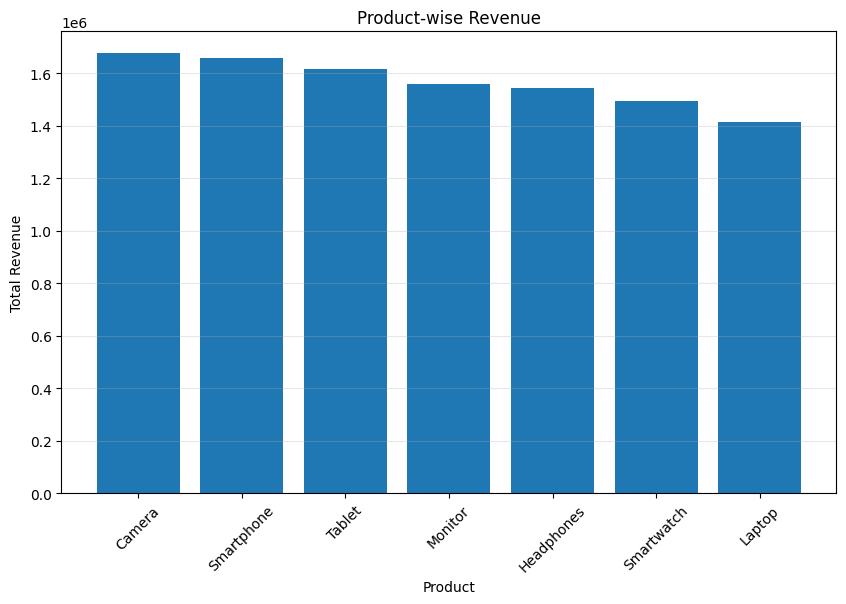

In [50]:
# product-wise Revenue

plt.figure(figsize=(10,6))
plt.bar(product_revenue.index,product_revenue.values)

plt.title('Product-wise Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

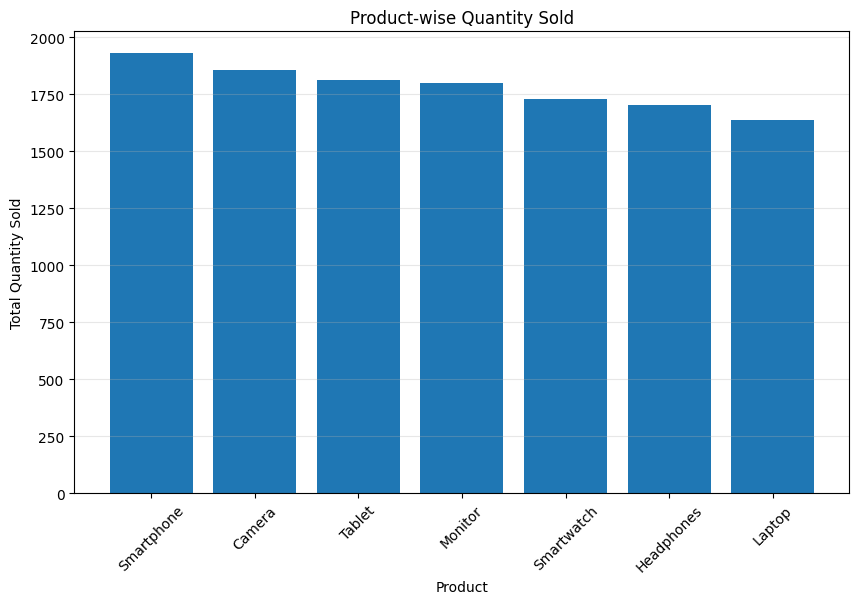

In [52]:
# Product-wise Quantity Sold


plt.figure(figsize=(10, 6))
plt.bar(product_quantity.index, product_quantity.values)

plt.title('Product-wise Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

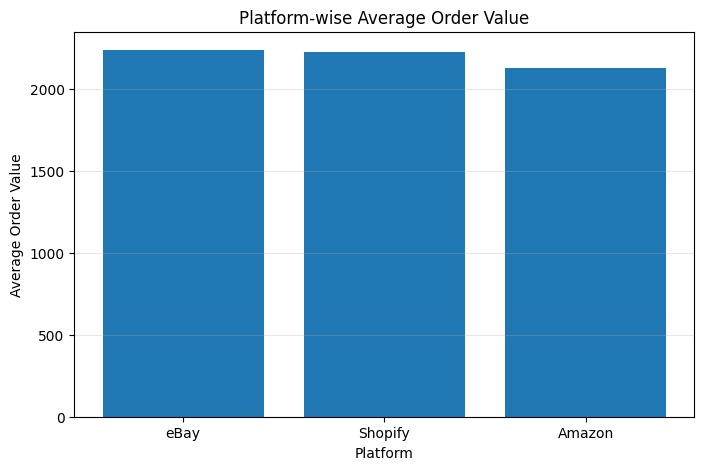

In [53]:
# Platform-wise Average Order Value (AOV)


plt.figure(figsize=(8, 5))
plt.bar(aov_platform.index, aov_platform.values)

plt.title('Platform-wise Average Order Value')
plt.xlabel('Platform')
plt.ylabel('Average Order Value')
plt.grid(axis='y', alpha=0.3)

plt.show()

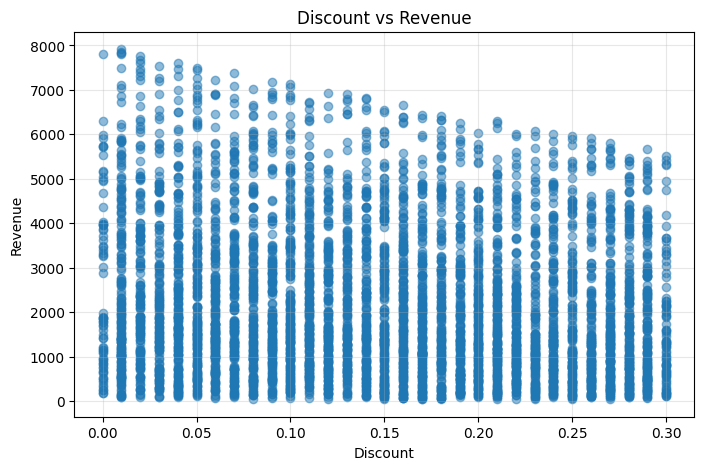

In [54]:
# Discount vs Revenue


plt.figure(figsize=(8, 5))

plt.scatter(df['Discount'], df['Revenue'], alpha=0.5)

plt.title('Discount vs Revenue')
plt.xlabel('Discount')
plt.ylabel('Revenue')

plt.grid(True, alpha=0.3)

plt.show()



In [55]:
# Correlation between Discount and Revenue

correlation = df['Discount'].corr(df['Revenue'])

print("Correlation between Discount and Revenue:", correlation)

Correlation between Discount and Revenue: -0.14890291095473368


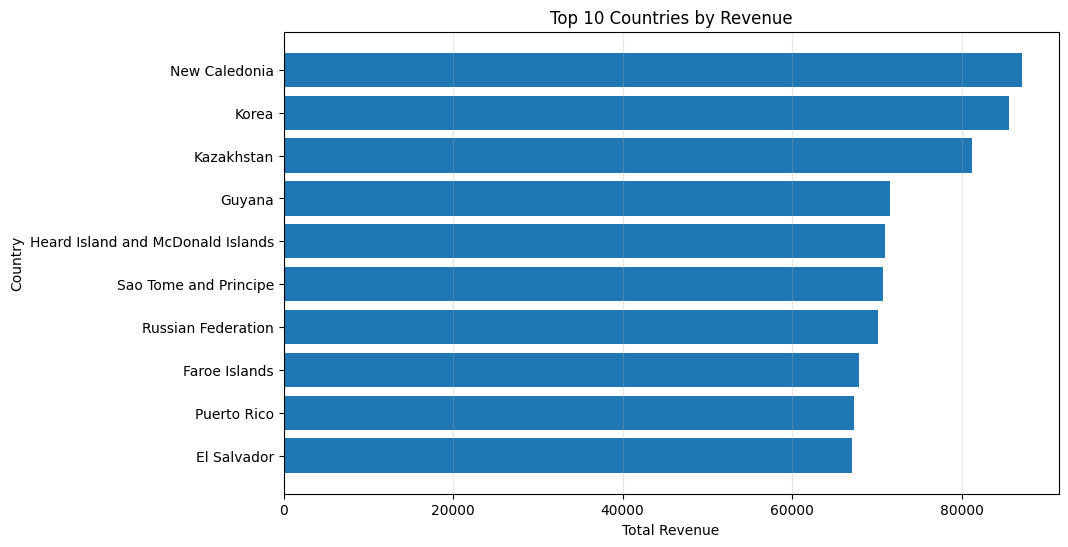

In [56]:
# Top 10 countries by Revenue
country_revenue = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index[::-1], country_revenue.values[::-1])

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)
plt.show()


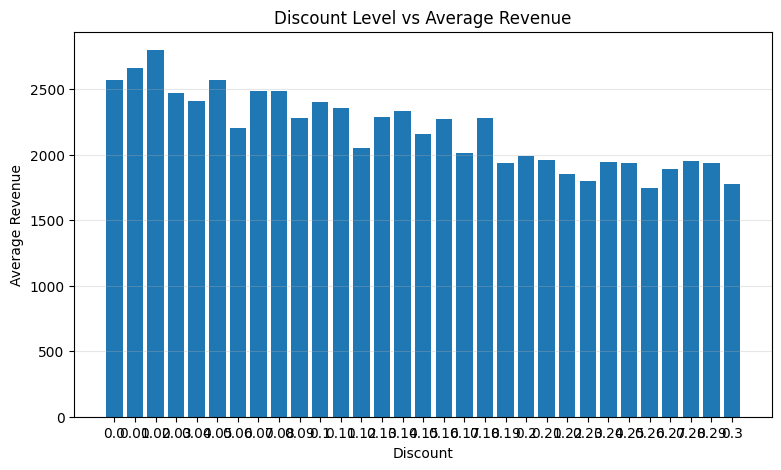

In [57]:
# Discount Level vs Average Revenue

discount_analysis = (
    df.groupby('Discount')['Revenue']
      .mean()
      .sort_index()
)

plt.figure(figsize=(9, 5))
plt.bar(
    discount_analysis.index.astype(str),
    discount_analysis.values
)

plt.title('Discount Level vs Average Revenue')
plt.xlabel('Discount')
plt.ylabel('Average Revenue')
plt.grid(axis='y', alpha=0.3)

plt.show()

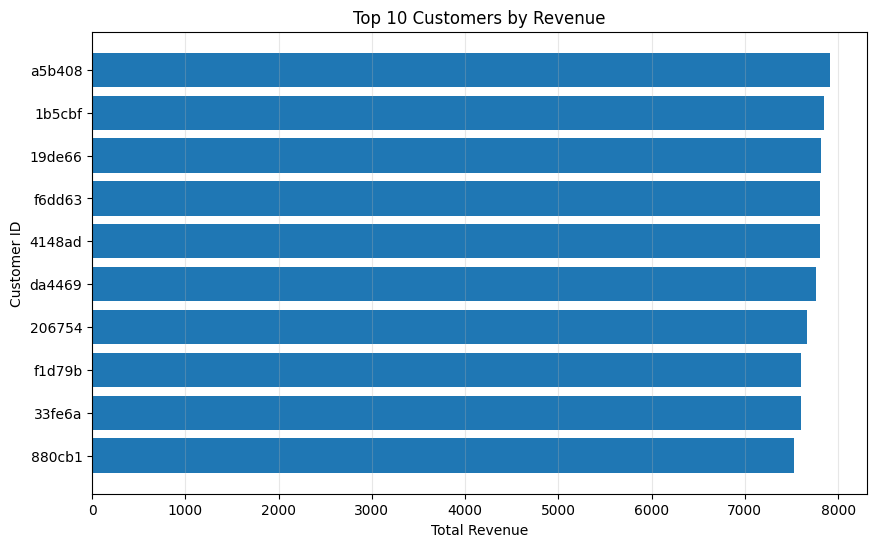

In [58]:
# Top 10 Customers by Revenue

customer_revenue = (
    df.groupby('Customer_ID')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    customer_revenue.index[::-1],
    customer_revenue.values[::-1]
)

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')

plt.grid(axis='x', alpha=0.3)

plt.show()

In [59]:
# Overall KPI Summary

total_revenue = df['Revenue'].sum()
total_orders = df['Order_ID'].nunique()
total_quantity = df['Quantity'].sum()
average_order_value = df['Revenue'].mean()
unique_customers = df['Customer_ID'].nunique()

print("========== E-COMMERCE SALES KPI ==========")
print(f"Total Revenue       : ₹{total_revenue:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Total Quantity      : {total_quantity:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Unique Customers    : {unique_customers:,}")

========== E-COMMERCE SALES KPI ==========
Total Revenue       : ₹10,961,418.65
Total Orders        : 5,000
Total Quantity      : 12,470
Average Order Value: ₹2,192.28
Unique Customers    : 5,000
